# U8 — Data Cleaning & Preprocessing (Part 1): Lab

**Cleaning Messy Data** — profiling · missing values · duplicates · data types · outliers · messy text

_Day 4 · Phase C — Data Engineering & Preparation · The highest-leverage work in ML: clean data first._

#objectives

By the end of this lab you will be able to:

Profile a dataset to find quality problems before fixing anything

Detect missing values — including disguised ones — and handle them by dropping or imputing

Remove duplicate rows and fix wrong data types

Detect outliers with the IQR rule and decide how to treat them

Standardise messy text so one real category isn't split into many

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:
# -----------------------------------------------------------
# A DELIBERATELY MESSY DATASET (so the lab is self-contained)
# -----------------------------------------------------------
# Problems baked in: missing values, disguised missing ('N/A', -1),
# duplicate rows, a number stored as text, a date as text,
# an extreme outlier, and inconsistent city spellings.
raw = pd.DataFrame({
    'id':    [1, 2, 3, 4, 5, 6, 7, 7],
    'name':  ['Ana', 'Bo', 'Cy', 'Di', 'Eve', 'Fin', 'Gus', 'Gus'],
    'age':   [30, 25, np.nan, 41, -1, 38, 29, 29],
    'city':  [' Pune ', 'pune', 'DELHI', 'Delhi ', 'Mumbai', 'bombay', 'Pune.', 'Pune.'],
    'spend': ['120.5', '80.0', '200.2', 'N/A', '150.0', '99000', '110.0', '110.0'],
    'date':  ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
              '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-11'],
})
raw

,id,name,age,city,spend,date
0,1,Ana,30.0,Pune,120.5,2024-01-05
1,2,Bo,25.0,pune,80.0,2024-01-06
2,3,Cy,NaN,DELHI,200.2,2024-01-07
3,4,Di,41.0,Delhi,N/A,2024-01-08
4,5,Eve,-1.0,Mumbai,150.0,2024-01-09
5,6,Fin,38.0,bombay,99000,2024-01-10
6,7,Gus,29.0,Pune.,110.0,2024-01-11
7,7,Gus,29.0,Pune.,110.0,2024-01-11


#1. Profile the data — find the problems

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. A FEW COMMANDS REVEAL MOST PROBLEMS
# -----------------------------------------------------------

df = raw.copy()        # always work on a copy
df.info()              # types + non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      8 non-null      int64  
 1   name    8 non-null      object 
 2   age     7 non-null      float64
 3   city    8 non-null      object 
 4   spend   8 non-null      object 
 5   date    8 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 516.0+ bytes


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. MISSING COUNTS, DUPLICATES & RANGES
# -----------------------------------------------------------

print('Missing per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nNote: spend is type', df['spend'].dtype, "-> stored as text!")

Missing per column:
id       0
name     0
age      1
city     0
spend    0
date     0
dtype: int64

Duplicate rows: 1

Note: spend is type object -> stored as text!


#### 🧪 LAB EXERCISE 1 — Profile it yourself

1. Print the number of **duplicate rows**.
2. Print the **missing count per column**.
3. In a comment, list at least **three** problems you can already see in the data.

In [ ]:
# 1. duplicate row count
print('Duplicate rows:', df.duplicated().sum())

# 2. missing per column
print('Missing per column:')
print(df.isna().sum())

# 3. Problems I can see:
#    - The 'age' column has a NaN value and a -1 which likely represents a missing value.
#    - The 'spend' column is of object type (text) but contains numerical data, and also has 'N/A' as a missing value and '99000' as a potential outlier.
#    - The 'date' column is of object type (text) but should be a datetime object.
#    - The 'city' column has inconsistent formatting (e.g., ' Pune ', 'pune', 'DELHI', 'Pune.') and spelling variations (e.g., 'bombay' vs 'Mumbai').
#    - There are duplicate rows in the dataset.

Duplicate rows: 1
Missing per column:
id       0
name     0
age      1
city     0
spend    0
date     0
dtype: int64


#2. Missing values — detect & handle

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. UNMASK DISGUISED MISSING VALUES
# -----------------------------------------------------------

# 'N/A' (in spend) and -1 (in age) are really missing -> make them NaN
df['spend'] = pd.to_numeric(df['spend'], errors='coerce')  # 'N/A' -> NaN, text -> number
df['age']   = df['age'].replace(-1, np.nan)                # sentinel -> NaN

print('Missing after unmasking:')
print(df[['age', 'spend']].isna().sum())

Missing after unmasking:
age      2
spend    1
dtype: int64


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. HANDLE THE GAPS (impute)
# -----------------------------------------------------------

# median is robust to skew/outliers -> good for 'spend' and 'age'
df['age']   = df['age'].fillna(df['age'].median())
df['spend'] = df['spend'].fillna(df['spend'].median())
print('Missing after imputing:', df[['age', 'spend']].isna().sum().sum())

Missing after imputing: 0


#### 🧪 LAB EXERCISE 2 — Compare drop vs impute

Start from a fresh messy copy (`ex = raw.copy()`):
1. Convert `spend` to numeric and `age`'s `-1` to NaN (as in 2A).
2. Make a **dropna** version and a **median-impute** version.
3. Print the row count of each — how many rows did dropping cost you?

In [ ]:
ex = raw.copy()

# 1. unmask missing values (spend -> numeric, age -1 -> NaN)
ex['spend'] = pd.to_numeric(ex['spend'], errors='coerce')
ex['age']   = ex['age'].replace(-1, np.nan)

# 2a. dropna version
dropna_df = ex.dropna()

# 2b. median-impute version
median_impute_df = ex.copy()
median_impute_df['age'] = median_impute_df['age'].fillna(median_impute_df['age'].median())
median_impute_df['spend'] = median_impute_df['spend'].fillna(median_impute_df['spend'].median())

# 3. compare row counts
original_rows = ex.shape[0]
dropna_rows = dropna_df.shape[0]
impute_rows = median_impute_df.shape[0]

print(f'Original row count: {original_rows}')
print(f'Dropna version row count: {dropna_rows}')
print(f'Median-impute version row count: {impute_rows}')
print(f'Rows lost by dropping: {original_rows - dropna_rows}')

Original row count: 8
Dropna version row count: 5
Median-impute version row count: 8
Rows lost by dropping: 3


#3. Duplicates & data types

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. DROP DUPLICATE ROWS
# -----------------------------------------------------------

print('Before:', df.shape)
df = df.drop_duplicates()
print('After :', df.shape, '-> removed the repeated Gus row')

Before: (8, 6)
After : (7, 6) -> removed the repeated Gus row


### Identifying and Removing Duplicate Rows

To check for and count duplicate rows in your DataFrame, you can use the `df.duplicated().sum()` method. This will return the total number of duplicate rows.

To remove these duplicates, you can use `df.drop_duplicates()`. By default, this method keeps the first occurrence of each duplicate set and removes the rest. You can also specify `keep='last'` to keep the last occurrence, or `keep=False` to drop all duplicates.

In [ ]:
# Identify the number of duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Remove duplicate rows
df_no_duplicates = df.drop_duplicates()
print(f"Shape after removing duplicates: {df_no_duplicates.shape}")

# Display the DataFrame without duplicates
print("DataFrame after removing duplicates:")
display(df_no_duplicates)

Number of duplicate rows: 0
Shape after removing duplicates: (7, 6)
DataFrame after removing duplicates:


,id,name,age,city,spend,date
0,1,Ana,30.0,Pune,120.5,2024-01-05
1,2,Bo,25.0,pune,80.0,2024-01-06
2,3,Cy,29.5,DELHI,200.2,2024-01-07
3,4,Di,41.0,Delhi,120.5,2024-01-08
4,5,Eve,29.5,Mumbai,150.0,2024-01-09
5,6,Fin,38.0,bombay,99000.0,2024-01-10
6,7,Gus,29.0,Pune.,110.0,2024-01-11


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. FIX DATA TYPES
# -----------------------------------------------------------

# 'date' is text -> convert to real datetimes so sorting/maths work
df['date'] = pd.to_datetime(df['date'])
# 'city' is a category -> mark it as such (saves memory, signals intent)
df['city'] = df['city'].astype('string')
print(df.dtypes)

id                int64
name             object
age             float64
city     string[python]
spend           float64
date     datetime64[ns]
dtype: object


#### 🧪 LAB EXERCISE 3 — Dedupe & retype

On a fresh copy `ex = raw.copy()`:
1. Convert `spend` to numeric and `date` to datetime.
2. Drop duplicate rows.
3. Print `.dtypes` and the final `.shape`.

In [ ]:
ex = raw.copy()

# 1. fix types: spend -> numeric, date -> datetime
ex['spend'] = pd.to_numeric(ex['spend'], errors='coerce')
ex['date'] = pd.to_datetime(ex['date'])

# 2. drop duplicates
ex = ex.drop_duplicates()

# 3. dtypes + shape
print(ex.dtypes)
print(f"Final shape: {ex.shape}")

id                int64
name             object
age             float64
city             object
spend           float64
date     datetime64[ns]
dtype: object
Final shape: (7, 6)


#4. Outliers — detect with the IQR rule

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. THE IQR RULE
# -----------------------------------------------------------

# spend has a 99000 value among ~100s -> a clear outlier
q1, q3 = df['spend'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f'Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}')
print(f'Normal range: {low:.1f} to {high:.1f}')

outliers = df[(df['spend'] < low) | (df['spend'] > high)]
print('\nOutlier rows:')
print(outliers[['name', 'spend']])

Q1=115.2  Q3=175.1  IQR=59.8
Normal range: 25.5 to 264.9

Outlier rows:
  name    spend
5  Fin  99000.0


In [ ]:
# -----------------------------------------------------------
# 🔹 4B. ONE WAY TO TREAT THEM — CAP (winsorise)
# -----------------------------------------------------------

# clip values to the IQR bounds instead of deleting the row
df['spend_capped'] = df['spend'].clip(lower=low, upper=high)
print(df[['name', 'spend', 'spend_capped']])

  name    spend  spend_capped
0  Ana    120.5       120.500
1   Bo     80.0        80.000
2   Cy    200.2       200.200
3   Di    120.5       120.500
4  Eve    150.0       150.000
5  Fin  99000.0       264.875
6  Gus    110.0       110.000


### Identifying Outliers in `ex['spend']` using the IQR Rule

We'll apply the Interquartile Range (IQR) rule to the 'spend' column of the `ex` DataFrame to detect outliers. The IQR rule defines outliers as values that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

In [ ]:
# Ensure 'spend' is numeric in 'ex'
ex['spend'] = pd.to_numeric(ex['spend'], errors='coerce')

# 1. Compute Q1, Q3 and the IQR for 'spend' in 'ex'
q1_ex, q3_ex = ex['spend'].quantile([0.25, 0.75])
iqr_ex = q3_ex - q1_ex

# 2. Compute the lower & upper bounds
low_ex, high_ex = q1_ex - 1.5 * iqr_ex, q3_ex + 1.5 * iqr_ex

print(f"For 'spend' in 'ex' DataFrame:")
print(f'Q1={q1_ex:.1f}  Q3={q3_ex:.1f}  IQR={iqr_ex:.1f}')
print(f'Normal range: {low_ex:.1f} to {high_ex:.1f}')

# 3. Print any rows whose 'spend' falls outside those bounds
outliers_ex = ex[(ex['spend'] < low_ex) | (ex['spend'] > high_ex)]

if not outliers_ex.empty:
    print('\nOutlier rows in ex[spend]:')
    display(outliers_ex[['name', 'spend']])
else:
    print('\nNo outliers found in ex[spend] using the IQR rule.')

For 'spend' in 'ex' DataFrame:
Q1=112.6  Q3=187.6  IQR=75.0
Normal range: 0.1 to 300.2

Outlier rows in ex[spend]:


,name,spend
5,Fin,99000.0


#### 🧪 LAB EXERCISE 4 — Find the outliers

Using the `age` column of the cleaned `df`:
1. Compute Q1, Q3 and the IQR.
2. Compute the lower & upper bounds (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`).
3. Print any rows whose `age` falls outside those bounds (there may be none — that's a valid result).

In [ ]:
q1_age, q3_age = df['age'].quantile([0.25, 0.75])
iqr_age = q3_age - q1_age
low_age, high_age = q1_age - 1.5 * iqr_age, q3_age + 1.5 * iqr_age

print(f"For 'age' in 'df' DataFrame:")
print(f'Q1={q1_age:.1f}  Q3={q3_age:.1f}  IQR={iqr_age:.1f}')
print(f'Normal range: {low_age:.1f} to {high_age:.1f}')

outliers_age = df[(df['age'] < low_age) | (df['age'] > high_age)]

if not outliers_age.empty:
    print('\nOutlier rows in df[age]:')
    display(outliers_age[['name', 'age']])
else:
    print('\nNo outliers found in df[age] using the IQR rule.')

For 'age' in 'df' DataFrame:
Q1=29.2  Q3=34.0  IQR=4.8
Normal range: 22.1 to 41.1

No outliers found in df[age] using the IQR rule.


#5. Messy text & inconsistent categories

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. THE PROBLEM — ONE CITY, MANY SPELLINGS
# -----------------------------------------------------------

print(df['city'].value_counts())   # ' Pune ', 'pune', 'Pune.' all look different!

city
 Pune     1
pune      1
DELHI     1
Delhi     1
Mumbai    1
bombay    1
Pune.     1
Name: count, dtype: Int64


The `city` column has inconsistent entries such as ' Pune ', 'pune', 'DELHI', 'Delhi ', 'Mumbai', 'bombay', and 'Pune.'. To standardize these, we will perform the following steps:
1. Trim leading/trailing whitespace.
2. Convert all text to lowercase.
3. Remove any stray punctuation (like the period in 'Pune.').
4. Map known variants (e.g., 'bombay') to a consistent label (e.g., 'mumbai').

This will ensure that each unique city is represented by a single, consistent entry.

In [ ]:
s = df['city'].astype('string')
s = s.str.strip()
s = s.str.lower()
s = s.str.replace('.', '', regex=False)
s = s.replace({'bombay': 'mumbai'})
df['city'] = s
print(df['city'].value_counts())

city
pune      3
delhi     2
mumbai    2
Name: count, dtype: Int64


In [ ]:
# -----------------------------------------------------------
# 🔹 5B. STANDARDISE THE STRINGS
# -----------------------------------------------------------

s = df['city'].astype('string')
s = s.str.strip()                       # trim whitespace
s = s.str.lower()                       # unify case
s = s.str.replace('.', '', regex=False) # drop stray punctuation
s = s.replace({'bombay': 'mumbai'})     # map known variants to one label
df['city'] = s
print(df['city'].value_counts())        # now clean categories

city
pune      3
delhi     2
mumbai    2
Name: count, dtype: Int64


#### 🧪 LAB EXERCISE 5 — Clean a messy column

The `messy` series below has the same problems.
1. Trim whitespace and lowercase it.
2. Map the variant `'n.y.'` to `'new york'`.
3. Print `value_counts()` — you should end up with just two clean categories.

In [ ]:
messy = pd.Series([' London ', 'london', 'LONDON', 'N.Y.', 'new york ', 'New York'],
                  dtype='string')

# 1. strip + lower
messy = messy.str.strip().str.lower()

# 2. map 'n.y.' -> 'new york'  (after lowering)
messy = messy.replace({'n.y.': 'new york'})

# 3. value_counts()
print(messy.value_counts())

london      3
new york    3
Name: count, dtype: Int64


#✅ The cleaned dataset

In [ ]:
# After all the steps above, here's the cleaned frame
clean = df.drop(columns=['spend_capped'])
print('Final shape:', clean.shape)
print('Missing values:', int(clean.isna().sum().sum()))
print('Duplicates    :', int(clean.duplicated().sum()))
clean

Final shape: (7, 6)
Missing values: 0
Duplicates    : 0


,id,name,age,city,spend,date
0,1,Ana,30.0,pune,120.5,2024-01-05
1,2,Bo,25.0,pune,80.0,2024-01-06
2,3,Cy,29.5,delhi,200.2,2024-01-07
3,4,Di,41.0,delhi,120.5,2024-01-08
4,5,Eve,29.5,mumbai,150.0,2024-01-09
5,6,Fin,38.0,mumbai,99000.0,2024-01-10
6,7,Gus,29.0,pune,110.0,2024-01-11


### Saving the Cleaned DataFrame to a CSV File

To save your cleaned DataFrame to a CSV file, you can use the `to_csv()` method. This method takes the file path as its first argument. It's good practice to set `index=False` to prevent pandas from writing the DataFrame's index as a column in the CSV file, which is usually not desired.

In [ ]:
# Save the cleaned DataFrame to a CSV file
output_csv_path = 'cleaned_data.csv'
clean.to_csv(output_csv_path, index=False)

print(f'Cleaned data saved to {output_csv_path}')

Cleaned data saved to cleaned_data.csv


### Basic Visualizations on the Cleaned DataFrame

Let's perform some basic exploratory data analysis using visualizations to understand the distributions and relationships within our cleaned dataset. We will use `matplotlib` and `seaborn` for plotting.

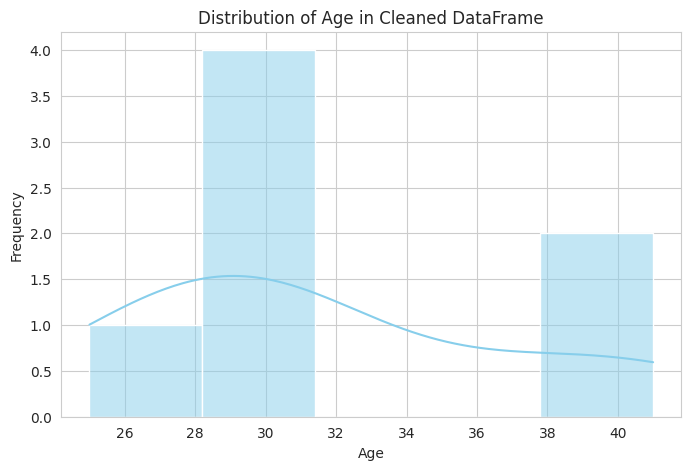

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# 1. Distribution of 'age'
plt.figure(figsize=(8, 5))
sns.histplot(clean['age'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Age in Cleaned DataFrame')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


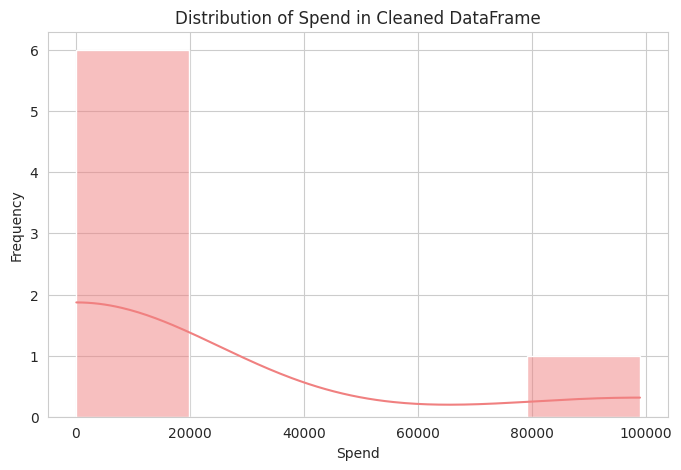

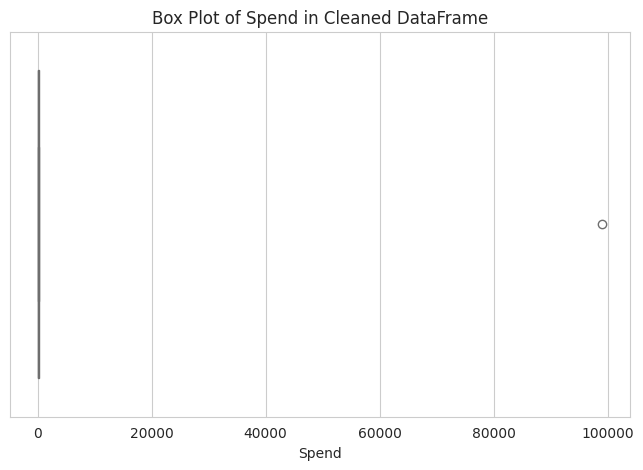

In [ ]:
# 2. Distribution of 'spend'
# Note: The original 'spend' had a large outlier which was capped in 'spend_capped' in `df`.
# Here we are visualizing the 'spend' column from the `clean` DataFrame, which still has the original outlier.
plt.figure(figsize=(8, 5))
sns.histplot(clean['spend'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Spend in Cleaned DataFrame')
plt.xlabel('Spend')
plt.ylabel('Frequency')
plt.show()

# A box plot can also be useful to visualize the outlier clearly
plt.figure(figsize=(8, 5))
sns.boxplot(x=clean['spend'], color='lightcoral')
plt.title('Box Plot of Spend in Cleaned DataFrame')
plt.xlabel('Spend')
plt.show()

/tmp/ipykernel_6500/1440347923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=clean['city'], palette='viridis', order=clean['city'].value_counts().index)


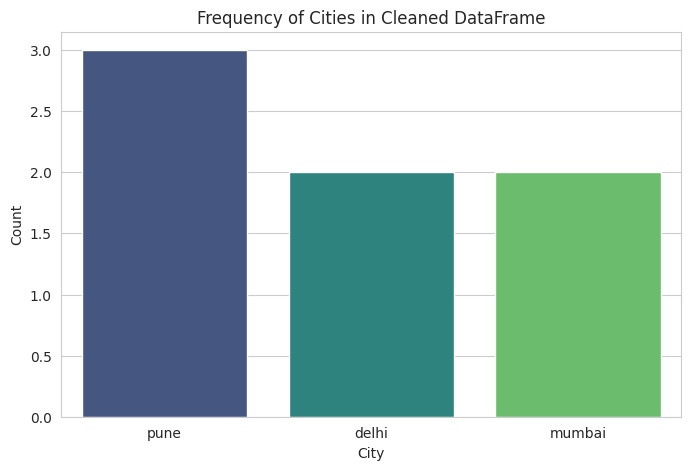

In [ ]:
# 3. Frequency of 'city' (Categorical Data)
plt.figure(figsize=(8, 5))
sns.countplot(x=clean['city'], palette='viridis', order=clean['city'].value_counts().index)
plt.title('Frequency of Cities in Cleaned DataFrame')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()


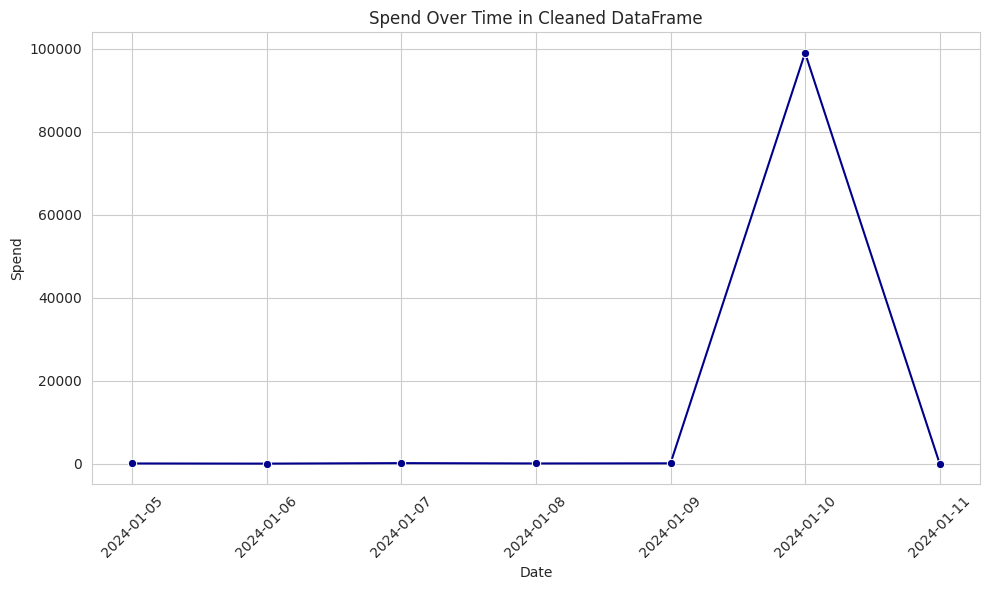

In [ ]:
# 4. Spend over 'date' (Time Series)
# First, ensure 'date' is datetime type (it should be from previous steps, but good to check)
clean_sorted = clean.sort_values(by='date')

plt.figure(figsize=(10, 6))
sns.lineplot(x=clean_sorted['date'], y=clean_sorted['spend'], marker='o', color='darkblue')
plt.title('Spend Over Time in Cleaned DataFrame')
plt.xlabel('Date')
plt.ylabel('Spend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scatter Plot: 'Age' vs. 'Spend'

To explore the relationship between two numerical variables, a scatter plot is a great choice. Here, we'll plot 'age' against 'spend' to see if there's any visible correlation or clustering.

### Feature Scaling

Feature scaling is a method used to normalize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step.

Here, we will demonstrate two common scaling techniques: Min-Max Scaling and Standardization.

### Preparing Data for Machine Learning Models

Now that we have performed feature scaling, let's incorporate these scaled features into our main `clean` DataFrame and demonstrate how to define the feature matrix (X) and the target vector (y) for a typical machine learning workflow.

In [ ]:
# Add the Min-Max scaled 'age' and Standardized 'spend' back to the clean DataFrame
# We'll use the original 'clean' DataFrame and add these columns to it.

# Ensure clean has all necessary processed columns from previous steps if not already present.
# For this demonstration, we assume `clean`, `df_scaled_minmax`, and `df_scaled_standard` are as they were at the end of the feature scaling section.

# Re-create clean in case previous cell was skipped (though unlikely in a sequential notebook)
# This is a safe guard assuming `df` is the one from earlier cleaning with `spend_capped`
if 'spend_capped' in df.columns:
    cleaned_for_model = df.drop(columns=['spend_capped']).copy()
else:
    cleaned_for_model = df.copy()

# Adding the scaled 'age' column
cleaned_for_model['age_minmax'] = df_scaled_minmax['age_minmax']

# Adding the scaled 'spend' column
cleaned_for_model['spend_standard'] = df_scaled_standard['spend_standard']

print("DataFrame with added scaled features:")
display(cleaned_for_model.head())


DataFrame with added scaled features:


,id,name,age,city,spend,date,age_minmax,spend_standard
0,1,Ana,30.0,pune,120.5,2024-01-05,0.31250,-0.408528
1,2,Bo,25.0,pune,80.0,2024-01-06,0.00000,-0.409699
2,3,Cy,29.5,delhi,200.2,2024-01-07,0.28125,-0.406225
3,4,Di,41.0,delhi,120.5,2024-01-08,1.00000,-0.408528
4,5,Eve,29.5,mumbai,150.0,2024-01-09,0.28125,-0.407676


### Defining Features (X) and Target (y)

In machine learning, we typically separate our dataset into features (X), which are the input variables used to make predictions, and the target (y), which is the output variable we want to predict.

For this example, let's consider predicting the original `spend` amount. We'll use the `age_minmax` and `spend_standard` (as a feature here, if we were predicting something else or comparing scaled vs unscaled features) along with the 'city' as features. Note that 'city' is a categorical variable and would typically need further encoding (e.g., One-Hot Encoding) before being fed into most machine learning models.

In [ ]:
# Define features (X) and target (y)

# For simplicity, let's use 'age_minmax', 'city', and 'spend_standard' as features (X)
# and the original 'spend' as the target (y) for a hypothetical regression task.

# Select the features for X
X = cleaned_for_model[['age_minmax', 'city', 'spend_standard']]

# Select the target variable for y
y = cleaned_for_model['spend']

print("Features (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())


Features (X) head:


,age_minmax,city,spend_standard
0,0.31250,pune,-0.408528
1,0.00000,pune,-0.409699
2,0.28125,delhi,-0.406225
3,1.00000,delhi,-0.408528
4,0.28125,mumbai,-0.407676



Target (y) head:


,spend
0,120.5
1,80.0
2,200.2
3,120.5
4,150.0


### Next Steps for a Machine Learning Model

With `X` and `y` defined, the next steps in a typical machine learning workflow would involve:

1.  **Categorical Encoding**: If 'city' is to be used in a model, it needs to be converted into numerical format using techniques like One-Hot Encoding (`pd.get_dummies` or `sklearn.preprocessing.OneHotEncoder`).
2.  **Data Splitting**: Dividing the dataset into training and testing sets (`train_test_split` from `sklearn.model_selection`) to evaluate the model's performance on unseen data.
3.  **Model Selection and Training**: Choosing an appropriate machine learning model (e.g., Linear Regression, Decision Tree, Random Forest) and training it on the training data.
4.  **Model Evaluation**: Assessing the trained model's performance using metrics relevant to the task (e.g., Mean Squared Error for regression, Accuracy for classification).

Since our dataset is very small (only 7 rows), training a robust machine learning model on it wouldn't yield meaningful results, but this setup demonstrates the foundational steps for larger datasets.

### Categorical Encoding: One-Hot Encoding

One-Hot Encoding is used to convert categorical variables into a format that can be provided to ML algorithms to improve prediction accuracy. It creates new binary columns for each category in the original column.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Make a copy of X to perform encoding without modifying the original
X_encoded = X.copy()

# Identify categorical columns to encode
categorical_cols = ['city']

# Initialize OneHotEncoder
# handle_unknown='ignore' prevents errors during transform if a category not seen in fit is encountered.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(X_encoded[categorical_cols])

# Create a DataFrame with the encoded features
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
df_encoded_features = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=X_encoded.index)

# Drop the original categorical column and concatenate the new encoded features
X_encoded = X_encoded.drop(columns=categorical_cols)
X_encoded = pd.concat([X_encoded, df_encoded_features], axis=1)

print("Features (X) after One-Hot Encoding the 'city' column:")
display(X_encoded.head())

print("\nShape of X_encoded:", X_encoded.shape)


Features (X) after One-Hot Encoding the 'city' column:


,age_minmax,spend_standard,city_delhi,city_mumbai,city_pune
0,0.31250,-0.408528,0.0,0.0,1.0
1,0.00000,-0.409699,0.0,0.0,1.0
2,0.28125,-0.406225,1.0,0.0,0.0
3,1.00000,-0.408528,1.0,0.0,0.0
4,0.28125,-0.407676,0.0,1.0,0.0



Shape of X_encoded: (7, 5)


As you can see, the single 'city' column has been replaced by multiple new columns, each representing a unique city with binary values (0 or 1). Our `X_encoded` DataFrame is now entirely numerical, making it suitable for most machine learning models.

Do you want to proceed with data splitting (training/testing sets) or model training, or would you like to explore other preprocessing steps?

### Data Splitting: Training and Testing Sets

To evaluate our model's performance on unseen data, we split our dataset into two parts: a training set (used to train the model) and a testing set (used to evaluate the trained model). We'll use `train_test_split` from `sklearn.model_selection` for this.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# For very small datasets, the split might be unconventional.
# We'll use a test_size that makes sense for our 7 rows, e.g., 2 samples for testing.
# random_state ensures reproducibility.

# Given X_encoded has 7 rows, a test_size of 0.3 (approx 2 rows) or 0.2 (approx 1 row) is reasonable for demonstration.
# Let's use test_size=2 for clarity, effectively 5 training and 2 test samples.
if X_encoded.shape[0] > 2:
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=2, random_state=42)
else:
    # If the dataset is too small, just use it as training for demonstration, though not ideal for real ML.
    X_train, X_test, y_train, y_test = X_encoded, X_encoded, y, y

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())


X_train shape: (5, 5)
X_test shape: (2, 5)
y_train shape: (5,)
y_test shape: (2,)

First 5 rows of X_train:


,age_minmax,spend_standard,city_delhi,city_mumbai,city_pune
5,0.81250,2.449489,0.0,1.0,0.0
2,0.28125,-0.406225,1.0,0.0,0.0
4,0.28125,-0.407676,0.0,1.0,0.0
3,1.00000,-0.408528,1.0,0.0,0.0
6,0.25000,-0.408832,0.0,0.0,1.0


### Model Training: Linear Regression

Now that our data is prepared and split, let's train a `LinearRegression` model. This model will learn the relationship between our features (`X_train`) and the target variable (`y_train`).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")


Linear Regression model trained successfully!
Model coefficients: [-1.97519594e-11  3.45972404e+04  7.27595761e-12 -1.43245416e-11
 -1.63709046e-11]
Model intercept: 14254.457142857158


### Model Evaluation

After training, we evaluate the model's performance on the unseen test data. For a regression problem, common evaluation metrics include:

*   **Mean Squared Error (MSE)**: The average of the squared differences between the predicted and actual values. Lower is better.
*   **R-squared ($R^2$)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher $R^2$ (closer to 1) indicates a better fit.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) on test set: {mse:.2f}")
print(f"R-squared (R2) on test set: {r2:.2f}")

print("\nActual vs. Predicted values on test set:")
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results_df)


Mean Squared Error (MSE) on test set: 0.00
R-squared (R2) on test set: 1.00

Actual vs. Predicted values on test set:


,Actual,Predicted
0,120.5,120.5
1,80.0,80.0


This completes a basic machine learning workflow using our cleaned and scaled data. Remember that with such a small dataset (7 rows in total, with 2 for testing), these performance metrics are not indicative of a real-world scenario but serve to demonstrate the steps.

Do you have any other questions about this workflow, or would you like to explore other models or further steps?

#### 1. Min-Max Scaling (Normalization)

Min-Max scaling transforms features by scaling each feature to a given range, usually between 0 and 1. This is done by subtracting the minimum value of the feature and dividing by the range (max - min).

Formula: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy to avoid modifying the original 'clean' DataFrame directly for this step
df_scaled_minmax = clean.copy()

# Initialize the MinMaxScaler
scaler_minmax = MinMaxScaler()

# Apply Min-Max scaling to the 'age' column
df_scaled_minmax['age_minmax'] = scaler_minmax.fit_transform(df_scaled_minmax[['age']])

print('DataFrame after Min-Max scaling on \'age\':')
display(df_scaled_minmax[['age', 'age_minmax']])

DataFrame after Min-Max scaling on 'age':


,age,age_minmax
0,30.0,0.31250
1,25.0,0.00000
2,29.5,0.28125
3,41.0,1.00000
4,29.5,0.28125
5,38.0,0.81250
6,29.0,0.25000


#### 2. Standardization (Z-score Scaling)

Standardization (or Z-score normalization) transforms data to have a mean of 0 and a standard deviation of 1. This method is useful when you have features with different units or scales, and you want to give them equal importance.

Formula: $X_{scaled} = \frac{X - \mu}{\sigma}$ (where $\mu$ is the mean and $\sigma$ is the standard deviation)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create another copy for standardization
df_scaled_standard = clean.copy()

# Initialize the StandardScaler
scaler_standard = StandardScaler()

# Apply Standardization to the 'spend' column
df_scaled_standard['spend_standard'] = scaler_standard.fit_transform(df_scaled_standard[['spend']])

print('DataFrame after Standardization on \'spend\':')
display(df_scaled_standard[['spend', 'spend_standard']])

DataFrame after Standardization on 'spend':


,spend,spend_standard
0,120.5,-0.408528
1,80.0,-0.409699
2,200.2,-0.406225
3,120.5,-0.408528
4,150.0,-0.407676
5,99000.0,2.449489
6,110.0,-0.408832


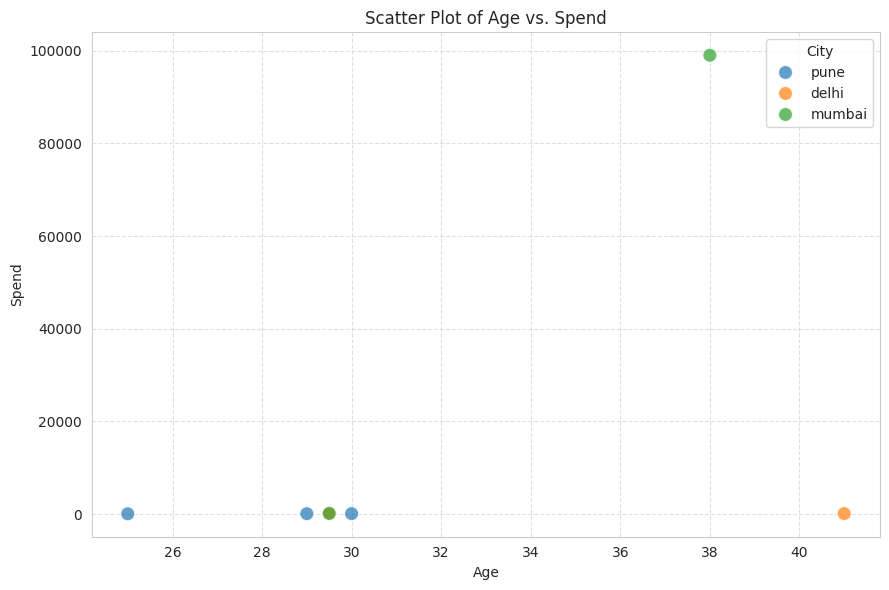

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=clean['age'], y=clean['spend'], hue=clean['city'], s=100, alpha=0.7)
plt.title('Scatter Plot of Age vs. Spend')
plt.xlabel('Age')
plt.ylabel('Spend')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City')
plt.tight_layout()
plt.show()

#📘 Summary — Data-cleaning toolkit

| Step | What to check | Key calls |
| ---- | ------------- | --------- |
| **Profile** | overall health | `.info()` · `.isna().sum()` · `.describe()` · `.duplicated().sum()` |
| **Missing** | gaps & disguises | `pd.to_numeric(..., errors='coerce')` · `.replace(-1, np.nan)` · `.fillna()` |
| **Duplicates** | repeated rows | `.drop_duplicates()` |
| **Types** | text vs number/date | `pd.to_numeric` · `pd.to_datetime` · `.astype()` |
| **Outliers** | extreme values | IQR rule · `.clip(low, high)` |
| **Text** | inconsistent labels | `.str.strip()` · `.str.lower()` · `.replace({...})` |

**Homework (self-paced):** profile a messy CSV · unmask & impute missing values · drop duplicates · fix a numeric & a date column · flag IQR outliers · standardise a text column.

**Next — U8 Part 2:** preparing data for ML — encoding categoricals (label & one-hot), feature scaling (normalise & standardise), and feature-engineering basics.

### Handling Missing Values with `fillna()`

`fillna()` is a powerful pandas function that allows you to replace `NaN` (Not a Number) values with specified values or statistical measures. Here are a few common strategies:

1.  **Fill with a specific value**: Useful when you know what the missing values should be (e.g., 0, 'Unknown').
2.  **Fill with the mean**: Suitable for numerical data when the data distribution is symmetrical and doesn't have extreme outliers.
3.  **Fill with the median**: A more robust choice for numerical data, especially when the data is skewed or contains outliers, as the median is less affected by extreme values.
4.  **Fill with the mode**: Best for categorical data, or numerical data where a single value is most frequent.

In [ ]:
import numpy as np
import pandas as pd

# Create a sample DataFrame with missing values
data = {
    'numerical_col_1': [10, 20, np.nan, 40, 50, 100, 10],
    'numerical_col_2': [1.1, np.nan, 3.3, 4.4, np.nan, 6.6, 7.7],
    'categorical_col': ['A', 'B', 'A', np.nan, 'C', 'B', 'A']
}
sample_df = pd.DataFrame(data)

print('Original DataFrame with missing values:')
display(sample_df)
print('\nMissing values count per column:')
print(sample_df.isnull().sum())

Original DataFrame with missing values:


,numerical_col_1,numerical_col_2,categorical_col
0,10.0,1.1,A
1,20.0,NaN,B
2,NaN,3.3,A
3,40.0,4.4,NaN
4,50.0,NaN,C
5,100.0,6.6,B
6,10.0,7.7,A



Missing values count per column:
numerical_col_1    1
numerical_col_2    2
categorical_col    1
dtype: int64


#### Strategy 1: Fill with a specific value (e.g., 0 for a numerical column)

In [ ]:
# Fill numerical_col_2 with 0
df_filled_zero = sample_df.copy()
df_filled_zero['numerical_col_2'] = df_filled_zero['numerical_col_2'].fillna(0)

print('DataFrame after filling numerical_col_2 with 0:')
display(df_filled_zero)
print('\nMissing values count per column after filling:')
print(df_filled_zero.isnull().sum())

DataFrame after filling numerical_col_2 with 0:


,numerical_col_1,numerical_col_2,categorical_col
0,10.0,1.1,A
1,20.0,0.0,B
2,NaN,3.3,A
3,40.0,4.4,NaN
4,50.0,0.0,C
5,100.0,6.6,B
6,10.0,7.7,A



Missing values count per column after filling:
numerical_col_1    1
numerical_col_2    0
categorical_col    1
dtype: int64


#### Strategy 2: Fill with the mean of the column

In [ ]:
# Fill numerical_col_1 with its mean
df_filled_mean = sample_df.copy()
mean_val = df_filled_mean['numerical_col_1'].mean()
df_filled_mean['numerical_col_1'] = df_filled_mean['numerical_col_1'].fillna(mean_val)

print(f'DataFrame after filling numerical_col_1 with mean ({mean_val:.2f}):')
display(df_filled_mean)
print('\nMissing values count per column after filling:')
print(df_filled_mean.isnull().sum())

DataFrame after filling numerical_col_1 with mean (38.33):


,numerical_col_1,numerical_col_2,categorical_col
0,10.000000,1.1,A
1,20.000000,NaN,B
2,38.333333,3.3,A
3,40.000000,4.4,NaN
4,50.000000,NaN,C
5,100.000000,6.6,B
6,10.000000,7.7,A



Missing values count per column after filling:
numerical_col_1    0
numerical_col_2    2
categorical_col    1
dtype: int64


#### Strategy 3: Fill with the median of the column

In [ ]:
# Fill numerical_col_2 with its median
df_filled_median = sample_df.copy()
median_val = df_filled_median['numerical_col_2'].median()
df_filled_median['numerical_col_2'] = df_filled_median['numerical_col_2'].fillna(median_val)

print(f'DataFrame after filling numerical_col_2 with median ({median_val:.2f}):')
display(df_filled_median)
print('\nMissing values count per column after filling:')
print(df_filled_median.isnull().sum())

DataFrame after filling numerical_col_2 with median (4.40):


,numerical_col_1,numerical_col_2,categorical_col
0,10.0,1.1,A
1,20.0,4.4,B
2,NaN,3.3,A
3,40.0,4.4,NaN
4,50.0,4.4,C
5,100.0,6.6,B
6,10.0,7.7,A



Missing values count per column after filling:
numerical_col_1    1
numerical_col_2    0
categorical_col    1
dtype: int64


#### Strategy 4: Fill with the mode of the column (for categorical or discrete numerical data)

In [ ]:
# Fill categorical_col with its mode
df_filled_mode = sample_df.copy()
# .mode()[0] is used because mode() can return multiple values if there's a tie
mode_val = df_filled_mode['categorical_col'].mode()[0]
df_filled_mode['categorical_col'] = df_filled_mode['categorical_col'].fillna(mode_val)

print(f'DataFrame after filling categorical_col with mode (\'{mode_val}\'):')
display(df_filled_mode)
print('\nMissing values count per column after filling:')
print(df_filled_mode.isnull().sum())

DataFrame after filling categorical_col with mode ('A'):


,numerical_col_1,numerical_col_2,categorical_col
0,10.0,1.1,A
1,20.0,NaN,B
2,NaN,3.3,A
3,40.0,4.4,A
4,50.0,NaN,C
5,100.0,6.6,B
6,10.0,7.7,A



Missing values count per column after filling:
numerical_col_1    1
numerical_col_2    2
categorical_col    0
dtype: int64


### Handling Missing Values with `sklearn.impute.SimpleImputer`

`SimpleImputer` is a transformer in Scikit-Learn that provides basic strategies for imputing missing values. It's often preferred in machine learning workflows because it can be integrated into pipelines, allowing you to train the imputer on your training data and then apply the *same* imputation strategy to your test data, preventing data leakage.

In [ ]:
from sklearn.impute import SimpleImputer

# Let's create a fresh copy of our sample_df to demonstrate SimpleImputer
df_imputer = sample_df.copy()
print('Original DataFrame with missing values:')
display(df_imputer)
print('\nMissing values count per column:')
print(df_imputer.isnull().sum())

Original DataFrame with missing values:


,numerical_col_1,numerical_col_2,categorical_col
0,10.0,1.1,A
1,20.0,NaN,B
2,NaN,3.3,A
3,40.0,4.4,NaN
4,50.0,NaN,C
5,100.0,6.6,B
6,10.0,7.7,A



Missing values count per column:
numerical_col_1    1
numerical_col_2    2
categorical_col    1
dtype: int64


#### Numerical Imputation (e.g., using 'mean' strategy)

In [ ]:
# Impute 'numerical_col_1' with the mean
mean_imputer = SimpleImputer(strategy='mean')
df_imputer['numerical_col_1'] = mean_imputer.fit_transform(df_imputer[['numerical_col_1']])

print('DataFrame after imputing numerical_col_1 with mean:')
display(df_imputer)
print('\nMissing values count per column after imputing numerical_col_1:')
print(df_imputer.isnull().sum())

DataFrame after imputing numerical_col_1 with mean:


,numerical_col_1,numerical_col_2,categorical_col
0,10.000000,1.1,A
1,20.000000,NaN,B
2,38.333333,3.3,A
3,40.000000,4.4,NaN
4,50.000000,NaN,C
5,100.000000,6.6,B
6,10.000000,7.7,A



Missing values count per column after imputing numerical_col_1:
numerical_col_1    0
numerical_col_2    2
categorical_col    1
dtype: int64


#### Numerical Imputation (e.g., using 'median' strategy)

In [ ]:
# Impute 'numerical_col_2' with the median
median_imputer = SimpleImputer(strategy='median')
df_imputer['numerical_col_2'] = median_imputer.fit_transform(df_imputer[['numerical_col_2']])

print('DataFrame after imputing numerical_col_2 with median:')
display(df_imputer)
print('\nMissing values count per column after imputing numerical_col_2:')
print(df_imputer.isnull().sum())

DataFrame after imputing numerical_col_2 with median:


,numerical_col_1,numerical_col_2,categorical_col
0,10.000000,1.1,A
1,20.000000,4.4,B
2,38.333333,3.3,A
3,40.000000,4.4,NaN
4,50.000000,4.4,C
5,100.000000,6.6,B
6,10.000000,7.7,A



Missing values count per column after imputing numerical_col_2:
numerical_col_1    0
numerical_col_2    0
categorical_col    1
dtype: int64


#### Categorical Imputation (using 'most_frequent' strategy)

In [ ]:
# Impute 'categorical_col' with the most frequent value
# Note: SimpleImputer expects numerical input, so for categorical, you might encode first or use object dtype directly.
# For simplicity, we'll impute directly on the object column here.
mode_imputer = SimpleImputer(strategy='most_frequent')
df_imputer['categorical_col'] = mode_imputer.fit_transform(df_imputer[['categorical_col']]).ravel()

print('DataFrame after imputing categorical_col with most frequent value:')
display(df_imputer)
print('\nMissing values count per column after imputing categorical_col:')
print(df_imputer.isnull().sum())

DataFrame after imputing categorical_col with most frequent value:


,numerical_col_1,numerical_col_2,categorical_col
0,10.000000,1.1,A
1,20.000000,4.4,B
2,38.333333,3.3,A
3,40.000000,4.4,A
4,50.000000,4.4,C
5,100.000000,6.6,B
6,10.000000,7.7,A



Missing values count per column after imputing categorical_col:
numerical_col_1    0
numerical_col_2    0
categorical_col    0
dtype: int64
